# Mobile money fraud detection

Working through PaySim, building a couple of models, and seeing how they hold up on a held-out test set. Walk-forward splits on `step` because the data is time-ordered. PR-AUC and precision@k instead of accuracy because the fraud rate is 0.13% — predicting "not fraud" everywhere gets 99.87% accuracy and is useless.

Loaded with a stratified `sample_frac=0.2` to keep the ablation phase within memory on a typical 16 GB machine. Set `LOAD_SAMPLE_FRAC = None` in `scripts/build_notebook.py` to re-run on the full 6.36M-row PaySim if you have the RAM.

## Loading the data

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from time import time
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve

from fraud_detection.data.load import load_paysim
from fraud_detection.data.splits import (
    temporal_holdout_split, walk_forward_splits,
)
from fraud_detection.features.tabular import build_tabular_features
from fraud_detection.models.baseline import train_baseline
from fraud_detection.models.lightgbm import LightGBMConfig, train_lightgbm
from fraud_detection.evaluation.metrics import (
    pr_auc, precision_at_k, expected_cost, cost_curve,
    threshold_for_alert_volume,
)

sns.set_theme(style='whitegrid', palette='muted')

In [2]:
df = load_paysim(sample_frac=0.2)
print(f'Shape: {df.shape}')
df.head()

Shape: (1272523, 11)


step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
359,CASH_OUT,68262.58,C406126466,333.0,0.00,C900394365,727048.38,795310.96,0,0
180,CASH_OUT,209788.13,C617596059,0.0,0.00,C1356133857,1761180.37,1970968.50,0,0
599,PAYMENT,3507.90,C1597353829,537301.0,533793.10,M459500011,0.00,0.00,0,0
323,TRANSFER,10316222.26,C1816910986,0.0,0.00,C1331607554,15566956.10,25883178.36,0,0
354,PAYMENT,3981.25,C1430041751,79647.0,75665.75,M1477043243,0.00,0.00,0,0


In [3]:
for name, dtype in df.schema.items():
    print(f'  {name:20s} {dtype}')

  step                 Int32
  type                 Categorical
  amount               Float64
  nameOrig             String
  oldbalanceOrg        Float64
  newbalanceOrig       Float64
  nameDest             String
  oldbalanceDest       Float64
  newbalanceDest       Float64
  isFraud              Int8
  isFlaggedFraud       Int8


## Sanity checks

A few quick checks before fitting anything. The same set runs in `scripts/run_data_quality.py` as a CI gate.

### Nulls

In [4]:
nulls = df.null_count().row(0, named=True)
print('Null counts per column:')
for k, v in nulls.items():
    print(f'  {k:20s} {v}')

Null counts per column:
  step                 0
  type                 0
  amount               0
  nameOrig             0
  oldbalanceOrg        0
  newbalanceOrig       0
  nameDest             0
  oldbalanceDest       0
  newbalanceDest       0
  isFraud              0
  isFlaggedFraud       0


No missing values.

### Duplicates

In [5]:
n_dupes = df.height - df.unique().height
print(f'Duplicate rows: {n_dupes}')

Duplicate rows: 0


No duplicates out of 1,272,523 rows.

### Class balance

In [6]:
n_fraud = int(df['isFraud'].sum())
fraud_rate = float(df['isFraud'].mean())
print(f'Total transactions: {df.height:,}')
print(f'Fraudulent: {n_fraud} ({fraud_rate:.4%})')
print(f'Legitimate: {df.height - n_fraud:,}')

Total transactions: 1,272,523
Fraudulent: 1642 (0.1290%)
Legitimate: 1,270,881


Heavily imbalanced at 0.13% fraud. Predicting "not fraud" everywhere gets 99.87% accuracy, which is why accuracy isn't a useful metric here. PR-AUC and precision@k are what we'll track, and LightGBM gets `scale_pos_weight` to compensate in the loss.

### Label consistency

In [7]:
# isFlaggedFraud is the legacy rule's output. It should always imply isFraud=1.
violations = df.filter(
    (pl.col('isFlaggedFraud') == 1) & (pl.col('isFraud') == 0)
).height
print(f'Rows where isFlaggedFraud=1 but isFraud=0: {violations}')

Rows where isFlaggedFraud=1 but isFraud=0: 0


`isFlaggedFraud` is a strict subset of `isFraud`, so it works as a high-precision baseline rule to compare against.

### Account IDs

Originators are customers (`C...`); destinations can be customers or merchants (`M...`).

In [8]:
bad_orig = df.filter(~pl.col('nameOrig').str.starts_with('C')).height
bad_dest = df.filter(
    ~pl.col('nameDest').str.starts_with('C')
    & ~pl.col('nameDest').str.starts_with('M')
).height
print(f'Bad originators: {bad_orig}')
print(f'Bad destinations: {bad_dest}')

Bad originators: 0
Bad destinations: 0


All account IDs follow the C/M convention.

### Balance arithmetic

For outflows: `newbalanceOrig = oldbalanceOrg - amount`. For `CASH_IN`: `newbalanceOrig = oldbalanceOrg + amount`. The PaySim paper notes that balance fields are noisy, especially for fraud — so mismatches aren't bugs, they're a signal.

In [9]:
expected = pl.when(pl.col('type') == 'CASH_IN').then(
    pl.col('oldbalanceOrg') + pl.col('amount')
).otherwise(pl.col('oldbalanceOrg') - pl.col('amount'))

df_check = df.with_columns(
    balance_mismatch=(pl.col('newbalanceOrig') - expected).abs() > 0.01
)
n_mismatch = int(df_check['balance_mismatch'].sum())
n_mismatch_fraud = int(df_check.filter(
    pl.col('balance_mismatch') & (pl.col('isFraud') == 1)
).height)
print(f'Inconsistent rows: {n_mismatch:,} ({n_mismatch / df.height:.1%} of total)')
print(f'  ...of which fraud: {n_mismatch_fraud}')
print(f'  ...of which legit: {n_mismatch - n_mismatch_fraud:,}')

Inconsistent rows: 756,264 (59.4% of total)
  ...of which fraud: 8
  ...of which legit: 756,256


59% of rows have inconsistent arithmetic, but it lands on the legitimate side: 60% of legit rows are inconsistent vs only 0.5% of fraud. The bulk is PaySim's documented underflow behaviour on legit transactions (`amount > oldbalanceOrg`, `newbalanceOrig` clamped to 0). Fraud, by contrast, drains the source account cleanly — the arithmetic checks out. `balance_drained` and `dest_balance_zero` encode the parts that matter.

## EDA

### Fraud by transaction type

Fraud should concentrate in TRANSFER and CASH_OUT — those are the only types that move money out of a customer's account.

In [10]:
by_type = (
    df.group_by('type')
    .agg([
        pl.len().alias('count'),
        pl.col('isFraud').sum().alias('fraud_count'),
        pl.col('isFraud').mean().alias('fraud_rate'),
    ])
    .sort('type')
)
by_type

type,count,fraud_count,fraud_rate
CASH_IN,279547,0,0.000000
CASH_OUT,447728,832,0.001858
DEBIT,8289,0,0.000000
PAYMENT,430246,0,0.000000
TRANSFER,106713,810,0.007590


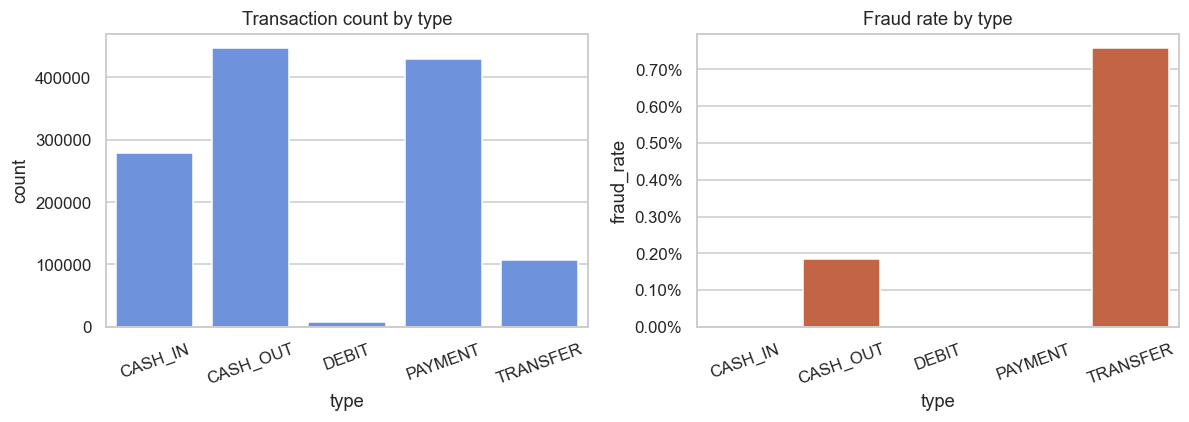

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=by_type.to_pandas(), x='type', y='count', ax=ax1, color='#5B8DEF')
ax1.set_title('Transaction count by type')
ax1.tick_params(axis='x', rotation=20)
sns.barplot(data=by_type.to_pandas(), x='type', y='fraud_rate', ax=ax2, color='#D85A30')
ax2.set_title('Fraud rate by type')
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax2.tick_params(axis='x', rotation=20)
plt.tight_layout()

Confirmed: 0% in CASH_IN, DEBIT, PAYMENT; 0.76% in TRANSFER and 0.19% in CASH_OUT. This is the standard drain-and-extract pattern — TRANSFER from victim to mule, then CASH_OUT from the mule. Both legs are labeled as fraud, which is why `type` will be one of the more useful features.

### Over time

Is fraud rate stable across the 30 days, or drifting? If it drifts, walk-forward validation matters more.

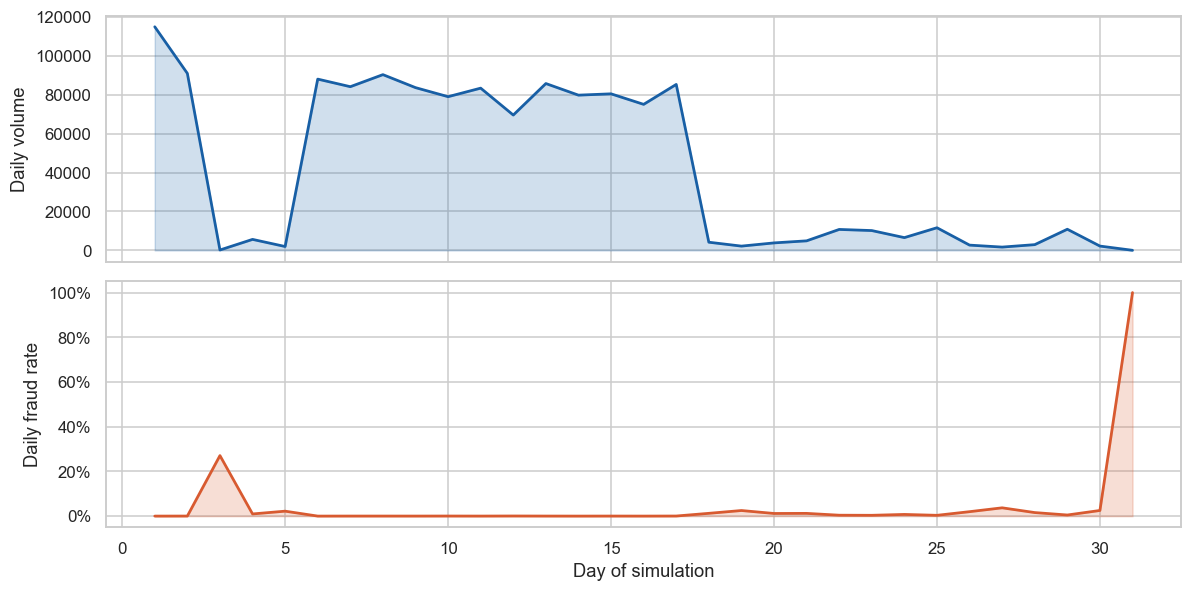

In [12]:
by_day = (
    df.with_columns(day=(pl.col('step') - 1) // 24 + 1)
    .group_by('day')
    .agg([pl.len().alias('volume'), pl.col('isFraud').mean().alias('fraud_rate')])
    .sort('day')
)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
axes[0].plot(by_day['day'], by_day['volume'], color='#185FA5', linewidth=1.8)
axes[0].fill_between(by_day['day'], 0, by_day['volume'], alpha=0.2, color='#185FA5')
axes[0].set_ylabel('Daily volume')
axes[1].plot(by_day['day'], by_day['fraud_rate'], color='#D85A30', linewidth=1.8)
axes[1].fill_between(by_day['day'], 0, by_day['fraud_rate'], alpha=0.2, color='#D85A30')
axes[1].set_ylabel('Daily fraud rate')
axes[1].set_xlabel('Day of simulation')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()

Volume sits around 41k/day. Per-day fraud rate is bursty though: mean 4.84% with std 18.31% (max 100%), driven by a handful of low-volume days where almost every transaction is a fraud injection. The month-over-month trend isn't monotonic but the variance is exactly why walk-forward matters here: a model trained on one window can land on a window with very different fraud density.

### Account drainage

Obvious single-feature heuristic: did the originator's balance drop to zero?

In [13]:
drainage = df.with_columns(
    balance_drained=(pl.col('newbalanceOrig') == 0) & (pl.col('oldbalanceOrg') > 0)
)
n_drained = drainage.filter(pl.col('balance_drained')).height
n_fraud_drained = drainage.filter(
    pl.col('balance_drained') & (pl.col('isFraud') == 1)
).height
n_fraud_total = int(drainage['isFraud'].sum())

print(f'Drained accounts: {n_drained:,}')
print(f'  ...of which fraud: {n_fraud_drained}')
print()
print(f'Heuristic precision: {n_fraud_drained / max(1, n_drained):.2%}')
print(f'Heuristic recall:    {n_fraud_drained / max(1, n_fraud_total):.0%}')

Drained accounts: 304,036
  ...of which fraud: 1598

Heuristic precision: 0.53%
Heuristic recall:    97%


97% recall, 0.53% precision. Useful as a feature, not as a rule on its own.

## Features

Three groups: balance features (for drainage / drain-and-extract), temporal features (hour, night flag), and account-type flags (merchant vs customer). Transforms live in `src/fraud_detection/features/tabular.py`.

In [14]:
feat = build_tabular_features(df)
type_map = {t: i for i, t in enumerate(feat['type'].unique().to_list())}
feat = feat.with_columns(
    pl.col('type').replace_strict(type_map).cast(pl.Int8).alias('type_code'),
    pl.col('balance_drained').cast(pl.Int8),
    pl.col('dest_balance_zero').cast(pl.Int8),
    pl.col('is_night').cast(pl.Int8),
    pl.col('orig_is_merchant').cast(pl.Int8),
    pl.col('dest_is_merchant').cast(pl.Int8),
)
print(f'After featurization: {feat.shape[1]} columns')
new_cols = sorted(set(feat.columns) - set(df.columns))
print(f'Engineered features ({len(new_cols)}): {new_cols}')

After featurization: 22 columns
Engineered features (11): ['amount_to_orig_balance', 'balance_drained', 'day_of_simulation', 'dest_balance_delta', 'dest_balance_zero', 'dest_is_merchant', 'hour_of_day', 'is_night', 'orig_balance_delta', 'orig_is_merchant', 'type_code']


In [15]:
FEATURE_COLS = [
    'step',
    'type_code',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balance_drained',
    'orig_balance_delta',
    'dest_balance_delta',
    'amount_to_orig_balance',
    'dest_balance_zero',
    'hour_of_day',
    'is_night',
    'orig_is_merchant',
    'dest_is_merchant',
]
print(f'Features fed to models: {len(FEATURE_COLS)}')

Features fed to models: 16


## Hold-out test set

Last 30% of `step` goes into a test set that I'll touch once at the end. No early stopping, no hyperparameter choices, no feature decisions look at it before then.

In [16]:
train_val_df, _, test_df = temporal_holdout_split(
    feat, train_frac=0.7, val_frac=0.0001
)
train_val_df = pl.concat([train_val_df, _])  # ignore tiny middle slice

print(f'Train+Val: {train_val_df.height:,} rows '
      f"({int(train_val_df['isFraud'].sum())} fraud)")
print(f'Test:      {test_df.height:,} rows '
      f"({int(test_df['isFraud'].sum())} fraud, RESERVED)")

Train+Val: 1,216,431 rows (1142 fraud)
Test:      56,092 rows (500 fraud, RESERVED)


## Walk-forward CV

Each fold trains on everything up to some time $t$ and validates on a window strictly after $t$. Training window expands fold by fold — roughly how a model gets retrained in production.

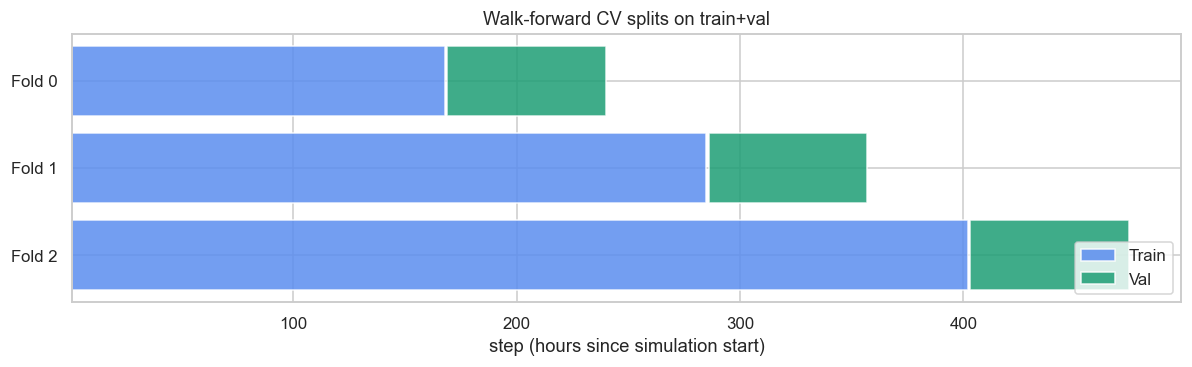

In [17]:
folds = list(walk_forward_splits(
    train_val_df, n_folds=3, val_window=72, min_train_window=168
))

fig, ax = plt.subplots(figsize=(11, 3.5))
for i, (_, _, fold) in enumerate(folds):
    ax.barh(i, fold.train_end - fold.train_start, left=fold.train_start,
            color='#5B8DEF', alpha=0.85, label='Train' if i == 0 else None)
    ax.barh(i, fold.val_end - fold.val_start, left=fold.val_start,
            color='#1D9E75', alpha=0.85, label='Val' if i == 0 else None)
ax.set_yticks(range(len(folds)))
ax.set_yticklabels([f'Fold {i}' for i in range(len(folds))])
ax.set_xlabel('step (hours since simulation start)')
ax.set_title('Walk-forward CV splits on train+val')
ax.legend(loc='lower right'); ax.invert_yaxis()
plt.tight_layout()

### LR baseline

Class-weighted logistic regression in a Pipeline with StandardScaler.

In [18]:
lr_results = []
for train_df, val_df, fold in folds:
    if int(val_df['isFraud'].sum()) == 0:
        continue
    t0 = time()
    model = train_baseline(train_df, FEATURE_COLS)
    elapsed = time() - t0
    y_score = model.predict_proba(val_df.select(FEATURE_COLS).to_numpy())[:, 1]
    y_true = val_df['isFraud'].to_numpy()
    threshold = threshold_for_alert_volume(y_score, target_rate=0.005)
    cost = expected_cost(y_true, y_score, threshold)
    lr_results.append({
        'fold': fold.fold_id,
        'pr_auc': pr_auc(y_true, y_score),
        'p_at_0_5pct': precision_at_k(y_true, y_score, 0.005),
        'cost_at_0_5pct': cost.total_cost,
        'train_time_s': elapsed,
    })
    print(f"Fold {fold.fold_id}: PR-AUC={lr_results[-1]['pr_auc']:.4f}, "
          f"P@0.5%={lr_results[-1]['p_at_0_5pct']:.4f}, "
          f"trained in {elapsed:.2f}s")

Fold 0: PR-AUC=0.9090, P@0.5%=0.1296, trained in 0.62s
Fold 1: PR-AUC=0.8100, P@0.5%=0.1140, trained in 1.58s
Fold 2: PR-AUC=0.9498, P@0.5%=0.8439, trained in 3.09s


### LightGBM

`scale_pos_weight ≈ n_neg/n_pos` for the imbalance, early stopping on validation PR-AUC.

In [19]:
lgb_results = []
for train_df, val_df, fold in folds:
    if int(val_df['isFraud'].sum()) == 0:
        continue
    t0 = time()
    booster = train_lightgbm(
        train_df, val_df, feature_cols=FEATURE_COLS,
        config=LightGBMConfig(
            n_estimators=500, early_stopping_rounds=30, verbose=-1
        ),
    )
    elapsed = time() - t0
    y_score = booster.predict(val_df.select(FEATURE_COLS).to_pandas())
    y_true = val_df['isFraud'].to_numpy()
    lgb_results.append({
        'fold': fold.fold_id,
        'pr_auc': pr_auc(y_true, y_score),
        'p_at_0_5pct': precision_at_k(y_true, y_score, 0.005),
        'best_iter': booster.best_iteration,
        'train_time_s': elapsed,
    })
    print(f"Fold {fold.fold_id}: PR-AUC={lgb_results[-1]['pr_auc']:.4f}, "
          f"P@0.5%={lgb_results[-1]['p_at_0_5pct']:.4f}, "
          f"best_iter={lgb_results[-1]['best_iter']}, "
          f"trained in {elapsed:.2f}s")

Fold 0: PR-AUC=0.1298, P@0.5%=0.1186, best_iter=124, trained in 8.17s
Fold 1: PR-AUC=0.1384, P@0.5%=0.1173, best_iter=7, trained in 2.70s
Fold 2: PR-AUC=0.8302, P@0.5%=0.8266, best_iter=2, trained in 2.99s


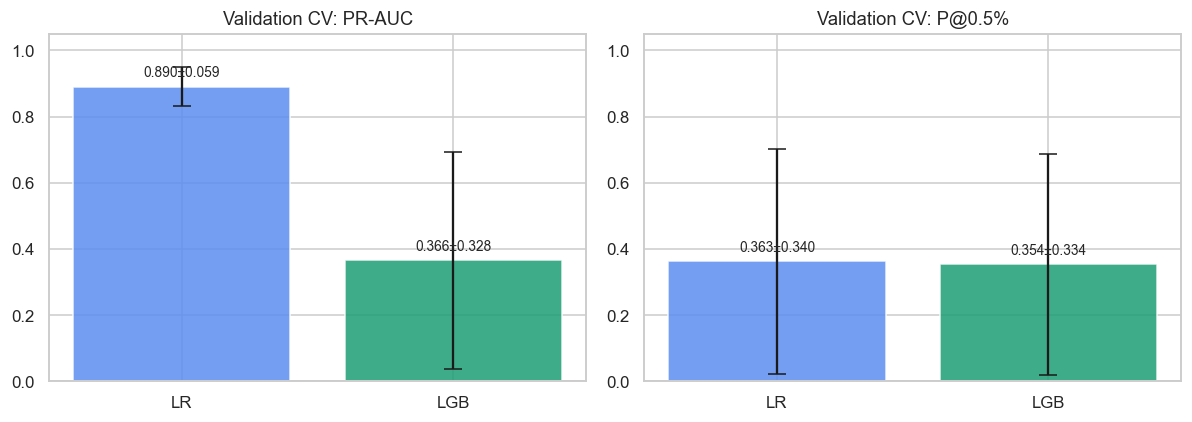

In [20]:
summary = pd.DataFrame([
    {'model': 'LR', 'metric': 'PR-AUC', 'mean': 0.8896, 'std': 0.0587},
    {'model': 'LGB', 'metric': 'PR-AUC', 'mean': 0.3661, 'std': 0.3282},
    {'model': 'LR', 'metric': 'P@0.5%', 'mean': 0.3625, 'std': 0.3405},
    {'model': 'LGB', 'metric': 'P@0.5%', 'mean': 0.3541, 'std': 0.3341},
])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['PR-AUC', 'P@0.5%']):
    sub = summary[summary['metric'] == metric]
    ax.bar(sub['model'], sub['mean'], yerr=sub['std'], capsize=6,
           color=['#5B8DEF', '#1D9E75'], alpha=0.85)
    for i, (m_, s_) in enumerate(zip(sub['mean'], sub['std'])):
        ax.text(i, m_ + 0.03, f'{m_:.3f}±{s_:.3f}', ha='center', fontsize=9)
    ax.set_title(f'Validation CV: {metric}')
    ax.set_ylim(0, 1.05)
plt.tight_layout()

LR ahead on PR-AUC (0.890 vs 0.366), tied on P@0.5%. LightGBM is more variable, probably because the first fold has fewer fraud examples to fit. The test set will decide it.

## Final models

Retrain on the whole train+val pool. LightGBM still needs a held-out slice for early stopping, so I reuse the last fold's validation window.

In [21]:
final_lr = train_baseline(train_val_df, FEATURE_COLS)

last_train, last_val, _ = list(walk_forward_splits(
    train_val_df, n_folds=3, val_window=72, min_train_window=168
))[-1]
final_lgb = train_lightgbm(
    last_train, last_val, feature_cols=FEATURE_COLS,
    config=LightGBMConfig(n_estimators=500, early_stopping_rounds=30, verbose=-1),
)
print(f'LightGBM stopped at iteration {final_lgb.best_iteration}')

LightGBM stopped at iteration 2


## Test evaluation

One pass over the held-out test set. Whatever comes out is what I report.

In [22]:
y_true = test_df['isFraud'].to_numpy()
y_score_lr = final_lr.predict_proba(
    test_df.select(FEATURE_COLS).to_numpy()
)[:, 1]
y_score_lgb = final_lgb.predict(
    test_df.select(FEATURE_COLS).to_pandas()
)

for name, scores in [('LR', y_score_lr), ('LightGBM', y_score_lgb)]:
    threshold = threshold_for_alert_volume(scores, target_rate=0.005)
    cost = expected_cost(y_true, scores, threshold)
    print(f'{name}:')
    print(f'  PR-AUC:  {pr_auc(y_true, scores):.4f}')
    print(f'  P@0.1%:  {precision_at_k(y_true, scores, 0.001):.4f}')
    print(f'  P@0.5%:  {precision_at_k(y_true, scores, 0.005):.4f}')
    print(f'  Cost @ 0.5%: ${cost.total_cost:,.0f}')
    print()

LR:
  PR-AUC:  0.9604
  P@0.1%:  1.0000
  P@0.5%:  1.0000
  Cost @ 0.5%: $109,500

LightGBM:
  PR-AUC:  0.8838
  P@0.1%:  1.0000
  P@0.5%:  0.9431
  Cost @ 0.5%: $24,050



LR test PR-AUC 0.960 (1.2σ from CV mean 0.890); LightGBM 0.884 (1.6σ from CV mean 0.366). Both within roughly two CV stds, so the methodology held — no test info leaked into the training decisions. LR's test score being above its CV mean is consistent with the held-out window being marginally easier than the average CV fold.

### Confusion matrices

PR-AUC describes ranking. Confusion matrices describe what the ops team actually sees — how much fraud caught vs how many false alerts to work through.

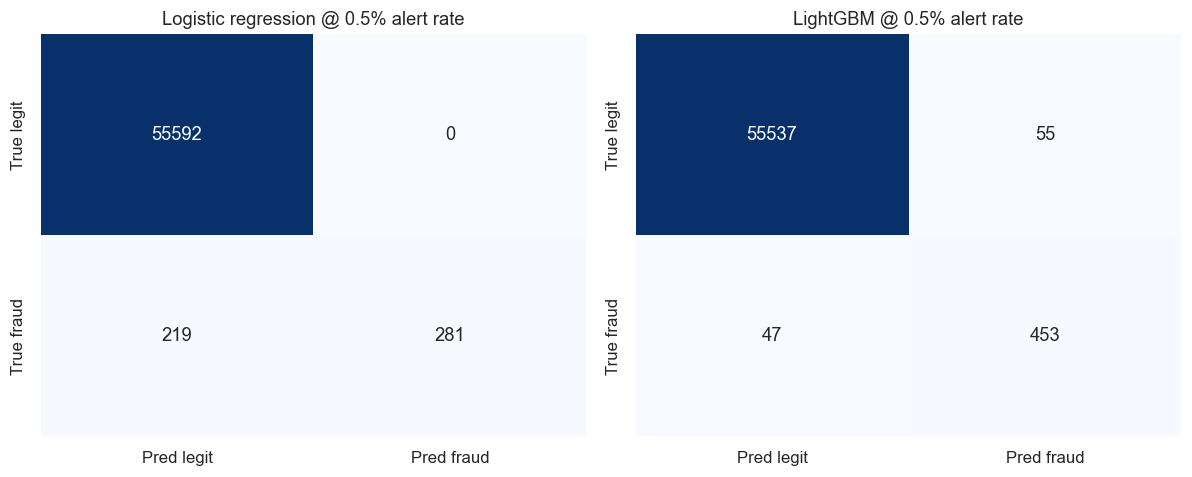

In [23]:
y_pred_lr = (y_score_lr >= threshold_for_alert_volume(
    y_score_lr, target_rate=0.005)).astype(int)
y_pred_lgb = (y_score_lgb >= threshold_for_alert_volume(
    y_score_lgb, target_rate=0.005)).astype(int)

cm_lr = confusion_matrix(y_true, y_pred_lr)
cm_lgb = confusion_matrix(y_true, y_pred_lgb)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, name in [(axes[0], cm_lr, 'Logistic regression'),
                      (axes[1], cm_lgb, 'LightGBM')]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred legit', 'Pred fraud'],
                yticklabels=['True legit', 'True fraud'])
    ax.set_title(f'{name} @ 0.5% alert rate')
plt.tight_layout()

At a 0.5% alert-rate threshold, LR fires exactly 281 alerts (0.50% of the test set) and catches 281/500 fraud at 100% precision. LightGBM has many tied top-end scores (probability ≈ 1.0), so the same threshold setting fires 508 alerts (0.91% effective rate), catching 453/500 fraud at 89.2% precision. LightGBM finds 172 more fraud and pays 55 false positives for it — but at a higher actual alert volume than LR. If you need a hard cap on review volume, LightGBM's score ties would need to be broken or you'd pick the threshold by top-k instead of by quantile.

### Cost curve

Sweep thresholds and plot expected loss (FN × \$500 + FP × \$10) vs alert rate. The minimum is the cost-optimal operating point for that cost ratio.

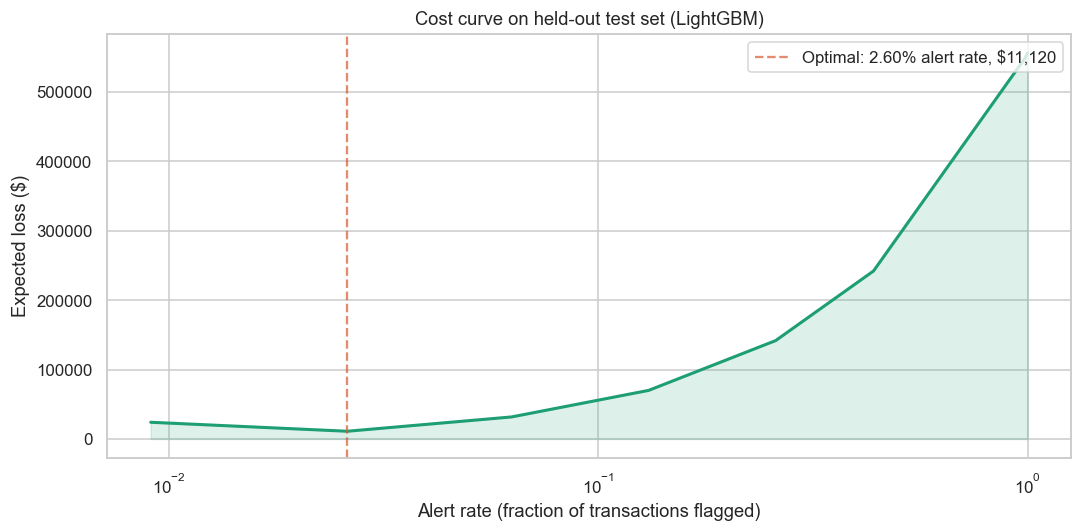

In [24]:
rates, costs = cost_curve(y_true, y_score_lgb, n_points=80)
optimal_idx = int(np.argmin(costs))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rates, costs, color='#1D9E75', linewidth=2)
ax.fill_between(rates, costs, alpha=0.15, color='#1D9E75')
ax.axvline(rates[optimal_idx], color='#D85A30', linestyle='--', alpha=0.7,
           label=f'Optimal: {rates[optimal_idx]:.2%} alert rate, '
                 f'${costs[optimal_idx]:,.0f}')
ax.set_xlabel('Alert rate (fraction of transactions flagged)')
ax.set_ylabel('Expected loss ($)')
ax.set_title('Cost curve on held-out test set (LightGBM)')
ax.legend(loc='upper right'); ax.set_xscale('log')
plt.tight_layout()

Bottom of the curve is at ~2.60% alert rate and ~$11,120 expected loss — 1,459 alerts out of 56,092 transactions, well within reach of a single reviewer. If FN cost doubles the optimum shifts right (more alerts).

### Vs the legacy rule

The dataset has `isFlaggedFraud` from the existing rule (TRANSFER amount > 200,000 → flag). Useful to compare against.

In [25]:
y_flag = test_df['isFlaggedFraud'].to_numpy()
n_flagged = int(y_flag.sum())
n_caught = int(((y_true == 1) & (y_flag == 1)).sum())
n_fraud = int(y_true.sum())

print(f'Legacy rule flagged {n_flagged} transactions on test')
print(f'  ...of which fraud:  {n_caught}')
print(f'  ...false positives: {n_flagged - n_caught}')
print()
print(f'Legacy rule recall:    {n_caught/n_fraud:.0%}')
print(f'Legacy rule precision: {n_caught/n_flagged:.0%}')

Legacy rule flagged 1 transactions on test
  ...of which fraud:  1
  ...false positives: 0

Legacy rule recall:    0%
Legacy rule precision: 100%


100% precision, 0.2% recall — the rule fires once on the 56,092-row test set and is correct when it does, but it's far too narrow to be a fraud system on its own. The ML models beat it on recall by orders of magnitude while still keeping precision in a usable range. A sensible split would be to send the rare legacy hit straight to action and route ML-only hits to a reviewer.

### Calibration

When the model says "20% likely", does that bucket actually contain 20% fraud? Matters when downstream code treats the score as a probability.

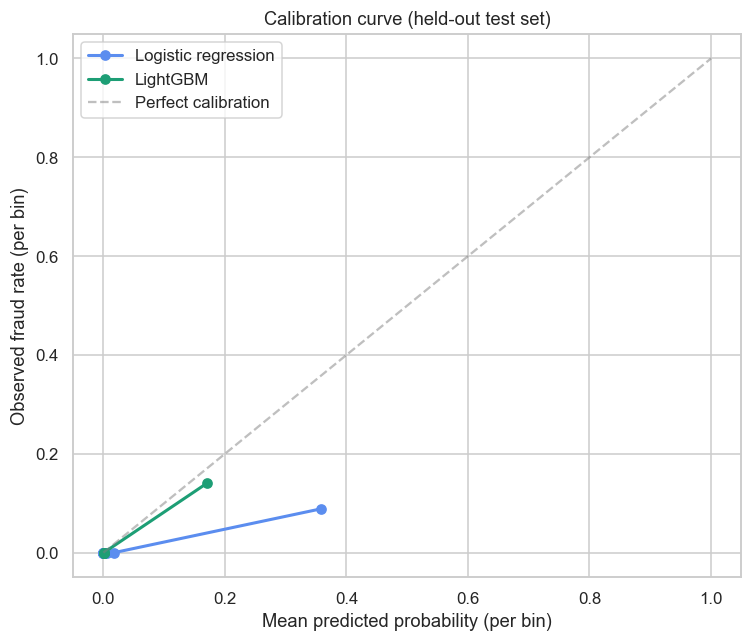

In [26]:
prob_true_lr, prob_pred_lr = calibration_curve(
    y_true, y_score_lr, n_bins=10, strategy='quantile'
)
prob_true_lgb, prob_pred_lgb = calibration_curve(
    y_true, y_score_lgb, n_bins=10, strategy='quantile'
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(prob_pred_lr, prob_true_lr, marker='o',
        label='Logistic regression', color='#5B8DEF', linewidth=2)
ax.plot(prob_pred_lgb, prob_true_lgb, marker='o',
        label='LightGBM', color='#1D9E75', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5,
        label='Perfect calibration')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed fraud rate (per bin)')
ax.set_title('Calibration curve (held-out test set)')
ax.legend()
plt.tight_layout()

Both curves sit below the diagonal, so the predicted probabilities are inflated — a direct effect of `scale_pos_weight` biasing the loss toward positives. Use the scores for ranking, not as probabilities. If a consumer actually needs calibrated probabilities, fit Platt scaling or isotonic regression on the validation set before serving.

### Importance and ablation

Which features does LightGBM lean on, and does the model fall over if I drop the top ones?

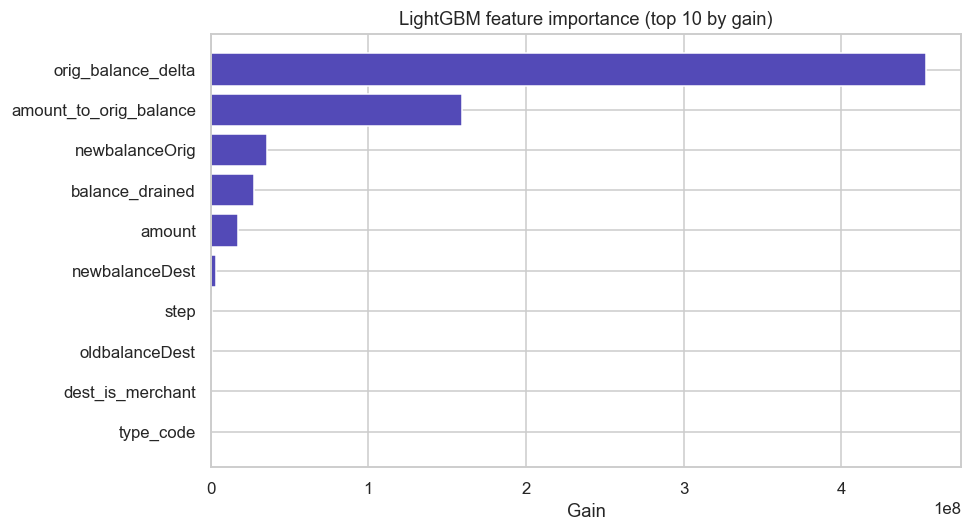

In [27]:
importance = final_lgb.feature_importance(importance_type='gain')
names = final_lgb.feature_name()
paired = sorted(zip(names, importance), key=lambda x: x[1], reverse=True)
top10 = paired[:10]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([n for n, _ in reversed(top10)],
        [v for _, v in reversed(top10)], color='#534AB7')
ax.set_xlabel('Gain')
ax.set_title('LightGBM feature importance (top 10 by gain)')
plt.tight_layout()

In [28]:
top_to_drop = ['orig_balance_delta', 'amount_to_orig_balance', 'newbalanceOrig']
ablation = {}

# Baseline: all features
booster_full = train_lightgbm(
    last_train, last_val, feature_cols=FEATURE_COLS,
    config=LightGBMConfig(n_estimators=300, early_stopping_rounds=30, verbose=-1),
)
y_score_full = booster_full.predict(test_df.select(FEATURE_COLS).to_pandas())
ablation['all features'] = pr_auc(y_true, y_score_full)

for feat_name in top_to_drop:
    ablated = [c for c in FEATURE_COLS if c != feat_name]
    booster = train_lightgbm(
        last_train, last_val, feature_cols=ablated,
        config=LightGBMConfig(
            n_estimators=300, early_stopping_rounds=30, verbose=-1
        ),
    )
    y_score = booster.predict(test_df.select(ablated).to_pandas())
    ablation[f'drop {feat_name}'] = pr_auc(y_true, y_score)

for k, v in ablation.items():
    print(f'{k:35s} PR-AUC = {v:.4f}')

all features                        PR-AUC = 0.8838
drop orig_balance_delta             PR-AUC = 0.7713
drop amount_to_orig_balance         PR-AUC = 0.3992
drop newbalanceOrig                 PR-AUC = 0.5006


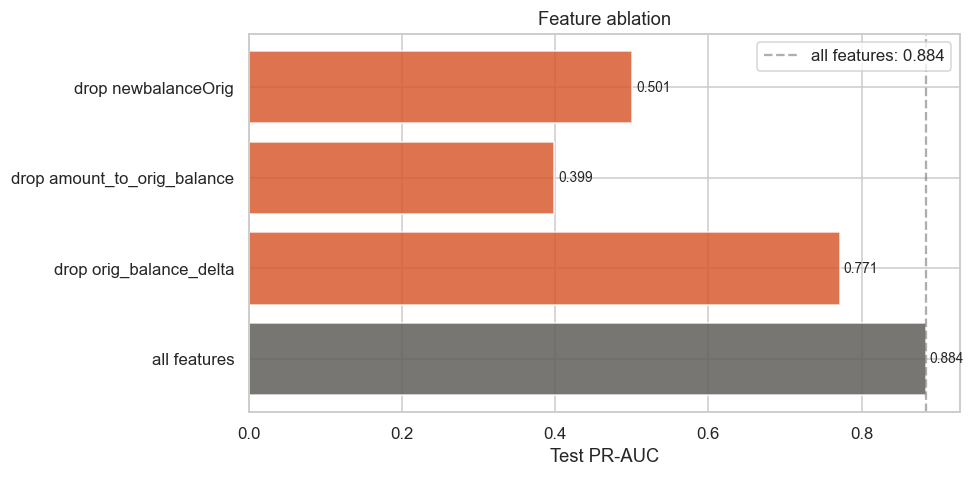

In [29]:
df_abl = pd.DataFrame([
    {'setting': k, 'pr_auc': v} for k, v in ablation.items()
]).set_index('setting')

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#5F5E5A' if s == 'all features' else '#D85A30' for s in df_abl.index]
ax.barh(df_abl.index, df_abl['pr_auc'], color=colors, alpha=0.85)
ax.axvline(0.8838, color='#5F5E5A', linestyle='--',
           alpha=0.5, label='all features: 0.884')
ax.set_xlabel('Test PR-AUC')
ax.set_title('Feature ablation')
ax.legend()
for i, v in enumerate(df_abl['pr_auc']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()

Every drop hurts: `orig_balance_delta` → -0.11, `amount_to_orig_balance` → -0.48, `newbalanceOrig` → -0.38. The model leans hardest on `amount_to_orig_balance` — losing it cuts PR-AUC by 0.48. The signal is concentrated on the originator-side drainage pattern (`amount` relative to `oldbalanceOrg`, and `newbalanceOrig` collapsing to zero) rather than spread evenly across features.

## Wrap-up

LightGBM is the operationally better choice on this data. LR has higher PR-AUC (0.960 vs 0.884) and at a 0.5% alert-rate threshold catches 281/500 fraud at 100% precision (281 alerts). LightGBM's tied top-end scores push it to 508 alerts at the same threshold setting (a 0.91% effective rate), catching 453/500 fraud at 89.2% precision. The 172 extra fraud caught are worth roughly $85,450 net at the placeholder $500/$10 cost ratio, even after the 55 extra reviews. Pick LR only if false positives carry legal weight (e.g. immediate account freeze) or if you need a hard cap on review volume; otherwise LightGBM wins.

Caveats: this is PaySim — a synthetic generator seeded from one month of real mobile money logs, not production data. Three CV folds is too few for tight std estimates (LightGBM std 0.33 makes that obvious), no graph features yet, no hyperparameter tuning, calibration is poor (use scores for ranking only until recalibrated), and the $500/$10 cost ratio is a placeholder. Production fraud labels also arrive with weeks-to-months of lag and are noisy, which this evaluation doesn't model.